# 자율주행 보조 시스템 — 최종 제출용 (Colab)
**KITTI 분석 → RetinaNet 학습+시각화 → ADAS 정확도 90%+**

루브릭 3개 항목을 모두 이 노트북 하나로 충족하도록 구성했습니다.

| # | 루브릭 | 이 노트북에서 담당하는 섹션 |
|---|---|---|
| ① | KITTI 데이터셋 체계적 분석 | 1~2절 |
| ② | RetinaNet 학습 + bbox 시각화 | 3~5절 |
| ③ | ADAS 테스트 90%+ 정확도 | 6절 |

**런타임 설정**: 상단 메뉴 `런타임 > 런타임 유형 변경 > GPU`를 꼭 켜주세요.


In [1]:
import torch
print("CUDA 사용 가능:", torch.cuda.is_available())
print("torch:", torch.__version__)


CUDA 사용 가능: True
torch: 2.11.0+cu128


## 1. KITTI 데이터셋 다운로드 (①)

약 12GB, 30~40분 정도 걸립니다. 한 번 받아두면 세션 안에서는 재사용됩니다.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as NF
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset, Subset, random_split

import os, copy, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

DATA_PATH = '/content/object_detection/data'
os.makedirs(DATA_PATH, exist_ok=True)


In [3]:
# torchvision이 제공하는 KITTI(2D object detection) 데이터셋을 내려받습니다.
kitti_train = torchvision.datasets.Kitti(root=DATA_PATH, train=True, download=True)
kitti_test  = torchvision.datasets.Kitti(root=DATA_PATH, train=False, download=True)

# KITTI의 8개 클래스('DontCare'는 제외)
KITTI_CLASSES = ['Car', 'Van', 'Truck', 'Pedestrian',
                 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
NAME_TO_ID = {name: i for i, name in enumerate(KITTI_CLASSES)}

def parse_kitti_target(target):
    """torchvision KITTI 타깃(list of dict) -> (boxes[xyxy px], class_ids)."""
    boxes, cls_ids = [], []
    for obj in (target or []):
        name = obj['type']
        if name not in NAME_TO_ID:
            continue
        boxes.append(obj['bbox'])
        cls_ids.append(NAME_TO_ID[name])
    boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    cls_ids = torch.tensor(cls_ids, dtype=torch.int64)
    return boxes, cls_ids

print(f"train 이미지 수: {len(kitti_train)}")
print(f"test  이미지 수: {len(kitti_test)}")
print(f"클래스({len(KITTI_CLASSES)}개): {KITTI_CLASSES}")


100%|██████████| 12.6G/12.6G [08:45<00:00, 23.9MB/s]
100%|██████████| 5.60M/5.60M [00:01<00:00, 5.40MB/s]


train 이미지 수: 7481
test  이미지 수: 7518
클래스(8개): ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']


## 2. 데이터셋 분석 (①)

샘플 이미지에 bbox를 그려 확인하고, train 전체(7,481장)의 클래스별 객체 수 분포를 집계합니다.
전체를 순회하므로 몇 분 정도 걸릴 수 있습니다.

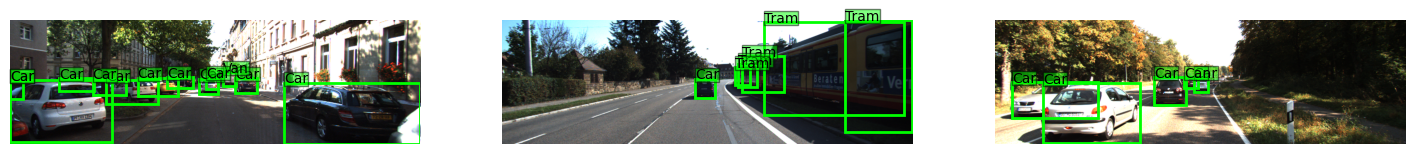

In [4]:
# 학습 이미지 3장을 bbox와 함께 확인
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, range(3)):
    image, target = kitti_train[idx]
    ax.imshow(image)
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x1, y1, x2, y2 = obj['bbox']
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1, obj['type'], color='black',
                bbox={'facecolor': 'lime', 'alpha': 0.5, 'pad': 0})
    ax.axis('off')
plt.show()


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

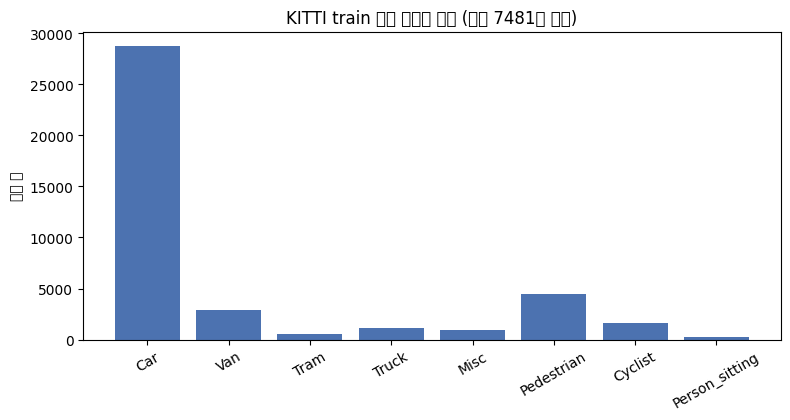

  Car            : 28742
  Pedestrian     : 4487
  Van            : 2914
  Cyclist        : 1627
  Truck          : 1094
  Misc           : 973
  Tram           : 511
  Person_sitting : 222


In [5]:
# 클래스별 객체 수 분포 (train 전체 기준)
class_counter = Counter()
for i in range(len(kitti_train)):
    _, target = kitti_train[i]
    for obj in target:
        if obj['type'] in NAME_TO_ID:
            class_counter[obj['type']] += 1

names = list(class_counter.keys())
counts = [class_counter[n] for n in names]

plt.figure(figsize=(9, 4))
plt.bar(names, counts, color="#4C72B0")
plt.title(f"KITTI train 객체 클래스 분포 (전체 {len(kitti_train)}장 기준)")
plt.ylabel("객체 수")
plt.xticks(rotation=30)
plt.show()

for n, c in sorted(class_counter.items(), key=lambda x: -x[1]):
    print(f"  {n:15s}: {c}")


첫 샘플 객체 수: 12


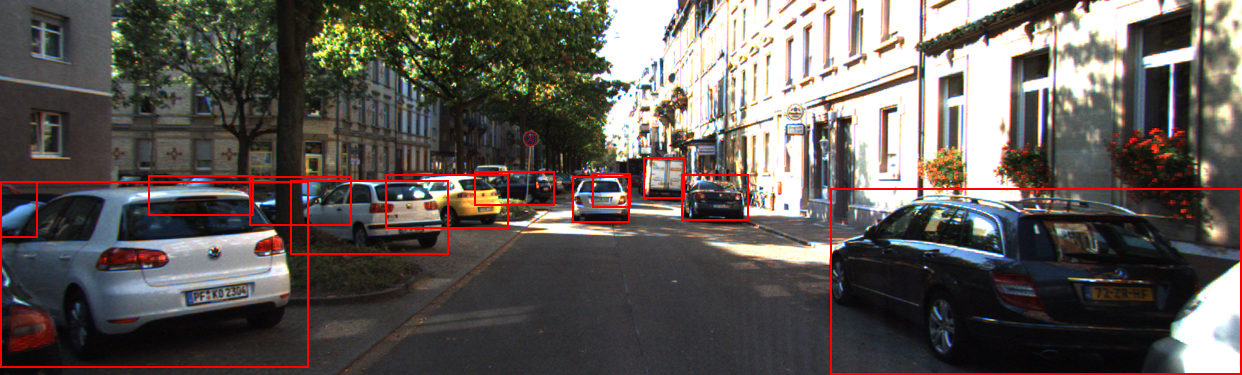

In [6]:
def visualize_bbox(input_image, target):
    input_image = copy.deepcopy(input_image)
    draw = ImageDraw.Draw(input_image)
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x_min, y_min, x_max, y_max = obj['bbox']
        draw.rectangle((x_min, y_min, x_max, y_max), outline=(255, 0, 0), width=2)
    return input_image

image, target = kitti_train[0]
print('첫 샘플 객체 수:', len(target))
visualize_bbox(image, target)


## 3. 데이터 파이프라인

In [7]:
def random_flip_horizontal(image, boxes):
    if torch.rand(1).item() > 0.5:
        _, _, width = image.shape
        image = TF.hflip(image)
        boxes = torch.stack(
            [width - boxes[:, 2], boxes[:, 1], width - boxes[:, 0], boxes[:, 3]], dim=-1
        )
    return image, boxes


def resize_and_pad_image(image, training=True):
    min_side = 800.0
    max_side = 1333.0
    min_side_range = [640, 1024]
    stride = 128.0

    image_shape = torch.tensor(image.shape[-2:], dtype=torch.float32)
    if training:
        min_side = torch.empty(1).uniform_(min_side_range[0], min_side_range[1]).item()
    ratio = min_side / torch.min(image_shape)
    if ratio * torch.max(image_shape) > max_side:
        ratio = max_side / torch.max(image_shape)
    new_shape = ratio * image_shape
    new_size = [int(new_shape[0].round().item()), int(new_shape[1].round().item())]
    image = TF.resize(image, new_size)

    padded = (torch.ceil(new_shape / stride) * stride).int().tolist()
    pad_h = padded[0] - new_size[0]
    pad_w = padded[1] - new_size[1]
    image = TF.pad(image, [0, 0, pad_w, pad_h])
    return image, torch.tensor(new_size, dtype=torch.float32), float(ratio)


def convert_to_xywh(boxes):
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0, boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )


def preprocess_data(image, boxes, class_ids):
    image, boxes = random_flip_horizontal(image, boxes)
    image, _, ratio = resize_and_pad_image(image)
    boxes = boxes * ratio
    boxes = convert_to_xywh(boxes)
    return image, boxes, class_ids


## 4. Anchor Box & Label Encoding

In [8]:
class AnchorBox:
    def __init__(self):
        self.aspect_ratios = [0.5, 1.0, 2.0]
        self.scales = [2 ** x for x in [0, 1 / 3, 2 / 3]]
        self._num_anchors = len(self.aspect_ratios) * len(self.scales)
        self._strides = [2 ** i for i in range(3, 8)]
        self._areas = [x ** 2 for x in [32.0, 64.0, 128.0, 256.0, 512.0]]
        self._anchor_dims = self._compute_dims()

    def _compute_dims(self):
        anchor_dims_all = []
        for area in self._areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area, dtype=torch.float32) / torch.tensor(ratio, dtype=torch.float32))
                anchor_width = torch.tensor(area, dtype=torch.float32) / anchor_height
                dims = torch.stack([anchor_width, anchor_height], dim=-1).view(1, 1, 2)
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))
        return anchor_dims_all

    def _get_anchors(self, feature_height, feature_width, level):
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        cx, cy = torch.meshgrid(rx, ry, indexing='xy')
        centers = torch.stack([cx, cy], dim=-1) * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)

    def get_anchors(self, image_height, image_width):
        anchors = [
            self._get_anchors(int(image_height / 2 ** i), int(image_width / 2 ** i), i)
            for i in range(3, 8)
        ]
        return torch.cat(anchors, dim=0)


def convert_to_corners(boxes):
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0, boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1,
    )


def compute_iou(boxes1, boxes2):
    boxes1_corners = convert_to_corners(boxes1)
    boxes2_corners = convert_to_corners(boxes2)
    lu = torch.maximum(boxes1_corners[:, None, :2], boxes2_corners[:, :2])
    rd = torch.minimum(boxes1_corners[:, None, 2:], boxes2_corners[:, 2:])
    intersection = torch.maximum(torch.tensor(0.0), rd - lu)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
    boxes1_area = boxes1[:, 2] * boxes1[:, 3]
    boxes2_area = boxes2[:, 2] * boxes2[:, 3]
    union_area = torch.maximum(
        boxes1_area[:, None] + boxes2_area - intersection_area, torch.tensor(1e-8)
    )
    return torch.clamp(intersection_area / union_area, min=0.0, max=1.0)


In [9]:
class LabelEncoder:
    def __init__(self):
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor([0.1, 0.1, 0.2, 0.2], dtype=torch.float32)

    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        iou_matrix = compute_iou(anchor_boxes, gt_boxes)
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        positive_mask = (max_iou >= match_iou).float()
        negative_mask = max_iou < ignore_iou
        ignore_mask = (~((max_iou >= match_iou) | negative_mask)).float()
        return matched_gt_idx, positive_mask, ignore_mask

    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        box_target = torch.cat(
            [
                (matched_gt_boxes[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
                torch.log(matched_gt_boxes[:, 2:] / anchor_boxes[:, 2:]),
            ],
            dim=-1,
        )
        return box_target / self._box_variance

    def _encode_sample(self, image_shape, gt_boxes, cls_ids):
        anchor_boxes = self._anchor_box.get_anchors(image_shape[0], image_shape[1])
        if gt_boxes.numel() == 0:
            box_target = torch.zeros_like(anchor_boxes)
            cls_target = torch.full((anchor_boxes.shape[0], 1), -1.0)
            return torch.cat([box_target, cls_target], dim=-1)

        cls_ids = cls_ids.float()
        matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(anchor_boxes, gt_boxes)
        matched_gt_boxes = gt_boxes[matched_gt_idx]
        box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
        matched_gt_cls_ids = cls_ids[matched_gt_idx]
        cls_target = torch.where(positive_mask != 1.0, torch.tensor(-1.0), matched_gt_cls_ids)
        cls_target = torch.where(ignore_mask == 1.0, torch.tensor(-2.0), cls_target)
        cls_target = cls_target.unsqueeze(-1)
        return torch.cat([box_target, cls_target], dim=-1)

    def encode_batch(self, batch_images, gt_boxes, cls_ids):
        N, _, H, W = batch_images.shape
        labels = [self._encode_sample((H, W), gt_boxes[i], cls_ids[i]) for i in range(N)]
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        batch_images = (batch_images - mean) / std
        return batch_images, torch.stack(labels, dim=0)


## 5. 모델(RetinaNet) & Loss (②)

In [10]:
class FeaturePyramid(nn.Module):
    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        self.conv_c3_1x1 = nn.Conv2d(512, 256, 1, 1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, 1, 1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, 1, 1, padding=0)
        self.conv_c3_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, 3, 2, padding=1)
        self.conv_c7_3x3 = nn.Conv2d(256, 256, 3, 2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, images):
        c3_output, c4_output, c5_output = self.backbone(images)
        p3_output = self.conv_c3_1x1(c3_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = p4_output + self.upsample_2x(p5_output)
        p3_output = p3_output + self.upsample_2x(p4_output)
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(NF.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output


def build_head(output_filters, bias_init):
    layers = []
    for _ in range(4):
        conv = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        nn.init.normal_(conv.weight, mean=0.0, std=0.01)
        nn.init.zeros_(conv.bias)
        layers.append(conv)
        layers.append(nn.ReLU())
    out_conv = nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1)
    nn.init.normal_(out_conv.weight, mean=0.0, std=0.01)
    if bias_init == "zeros":
        nn.init.zeros_(out_conv.bias)
    else:
        nn.init.constant_(out_conv.bias, float(bias_init))
    layers.append(out_conv)
    return nn.Sequential(*layers)


class Backbone(nn.Module):
    """ResNet50(ImageNet pretrained)에서 C3, C4, C5 특성 맵을 뽑아 반환."""
    def __init__(self):
        super(Backbone, self).__init__()
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5


def get_backbone():
    return Backbone()


class RetinaNet(nn.Module):
    def __init__(self, num_classes, backbone):
        super(RetinaNet, self).__init__()
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes
        prior_probability = -torch.log(torch.tensor((1 - 0.01) / 0.01))
        self.cls_head = build_head(9 * num_classes, prior_probability)
        self.box_head = build_head(9 * 4, "zeros")

    def forward(self, image):
        features = self.fpn(image)
        N = image.size(0)
        cls_outputs, box_outputs = [], []
        for feature in features:
            box_outputs.append(self.box_head(feature).permute(0, 2, 3, 1).reshape(N, -1, 4))
            cls_outputs.append(self.cls_head(feature).permute(0, 2, 3, 1).reshape(N, -1, self.num_classes))
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)


In [11]:
class RetinaNetBoxLoss(nn.Module):
    def __init__(self, delta):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta

    def forward(self, y_true, y_pred):
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5,
        )
        return torch.sum(loss, dim=-1)


class RetinaNetClassificationLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super(RetinaNetClassificationLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma

    def forward(self, y_true, y_pred):
        cross_entropy = NF.binary_cross_entropy_with_logits(y_pred, y_true, reduction='none')
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true == 1.0, torch.tensor(self._alpha), torch.tensor(1.0 - self._alpha))
        pt = torch.where(y_true == 1.0, probs, 1 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy
        return torch.sum(loss, dim=-1)


class RetinaNetLoss(nn.Module):
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = RetinaNetClassificationLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes

    def forward(self, y_true, y_pred):
        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]

        cls_ids = y_true[:, :, 4]
        positive_mask = (cls_ids > -1.0).float()
        ignore_mask = (cls_ids == -2.0).float()

        cls_target_idx = cls_ids.clamp(min=0).long()
        cls_labels = NF.one_hot(cls_target_idx, num_classes=self._num_classes).float()
        cls_labels = cls_labels * positive_mask.unsqueeze(-1)

        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        box_loss = self._box_loss(box_labels, box_predictions)

        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        box_loss = torch.where(positive_mask == 1.0, box_loss, torch.zeros_like(box_loss))

        normalizer = torch.clamp(positive_mask.sum(dim=-1), min=1.0)
        clf_loss = clf_loss.sum(dim=-1) / normalizer
        box_loss = box_loss.sum(dim=-1) / normalizer
        return (clf_loss + box_loss).mean()


In [12]:
num_classes = 8
batch_size = 2

resnet50_backbone = get_backbone()
loss_fn = RetinaNetLoss(num_classes)
model = RetinaNet(num_classes, resnet50_backbone)
print("모델 준비 완료")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


모델 준비 완료


In [13]:
learning_rates = [2.5e-06, 0.000625, 0.00125, 0.0025, 0.00025, 2.5e-05]
learning_rate_boundaries = [125, 250, 500, 240000, 360000]
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rates[0], momentum=0.9)

def lr_lambda(step):
    for i, boundary in enumerate(learning_rate_boundaries):
        if step < boundary:
            return learning_rates[i] / learning_rates[0]
    return learning_rates[-1] / learning_rates[0]

scheduler = LambdaLR(optimizer, lr_lambda)


In [14]:
label_encoder = LabelEncoder()

class KITTIDetection(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, target = self.base[idx]
        boxes, class_ids = parse_kitti_target(target)
        image = TF.to_tensor(image)
        image, boxes, class_ids = preprocess_data(image, boxes, class_ids)
        return image, boxes, class_ids


def make_collate_fn(label_encoder):
    def collate_fn(batch):
        images, boxes, cls_ids = zip(*batch)
        max_h = max(img.shape[1] for img in images)
        max_w = max(img.shape[2] for img in images)
        padded = []
        for img in images:
            pad_h = max_h - img.shape[1]
            pad_w = max_w - img.shape[2]
            padded.append(NF.pad(img, (0, pad_w, 0, pad_h)))
        images = torch.stack(padded)
        images, labels = label_encoder.encode_batch(images, list(boxes), list(cls_ids))
        return images, labels
    return collate_fn

collate_fn = make_collate_fn(label_encoder)
full_dataset = KITTIDetection(kitti_train)
print(f"전체 학습 가능 이미지: {len(full_dataset)}장")


전체 학습 가능 이미지: 7481장


### 실제 학습 실행 (②)

`SUBSET_SIZE`, `EPOCHS`로 학습 시간을 조절하세요.

- Colab T4 GPU 기준 800장 x 3epoch ≈ 40~70분 정도가 목표치입니다.
- 시간이 더 있다면 `SUBSET_SIZE`를 늘리거나 `None`으로 두면 전체 7,481장을 사용합니다.
- 이 셀은 **다시 실행하면 기존 체크포인트(`latest_checkpoint.pth`)를 이어받아 추가 학습**합니다 — 세션이 끊겨도 이어서 돌릴 수 있어요.

In [15]:
SUBSET_SIZE = 800     # None 이면 KITTI train 전체(7,481장) 사용
EPOCHS = 3

CHECKPOINT_DIR = os.path.join(DATA_PATH, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
LATEST_CKPT = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("학습 디바이스:", device)

start_epoch = 0
if os.path.exists(LATEST_CKPT):
    ckpt = torch.load(LATEST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    print(f"기존 체크포인트 발견 — epoch {start_epoch}부터 이어서 학습합니다.")

if SUBSET_SIZE is not None and SUBSET_SIZE < len(full_dataset):
    subset_indices = torch.randperm(len(full_dataset))[:SUBSET_SIZE].tolist()
    training_pool = Subset(full_dataset, subset_indices)
else:
    training_pool = full_dataset

val_size = max(1, int(len(training_pool) * 0.1))
train_size = len(training_pool) - val_size
train_dataset, val_dataset = random_split(training_pool, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                           drop_last=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                         drop_last=True, collate_fn=collate_fn, num_workers=2)

print(f"학습 {len(train_dataset)}장 / 검증 {len(val_dataset)}장")

for epoch in range(start_epoch, start_epoch + EPOCHS):
    model.train()
    epoch_start = time.time()
    running_loss = 0.0
    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(labels, preds)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        if step % 20 == 0:
            print(f"  epoch {epoch} step {step}/{len(train_loader)} loss {loss.item():.4f}")

    avg_loss = running_loss / max(1, len(train_loader))
    elapsed = (time.time() - epoch_start) / 60
    print(f"[epoch {epoch}] 평균 loss={avg_loss:.4f}  소요={elapsed:.1f}분")

    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": avg_loss,
    }
    torch.save(ckpt, os.path.join(CHECKPOINT_DIR, f"weights_epoch_{epoch}.pth"))
    torch.save(ckpt, LATEST_CKPT)
    print(f"  체크포인트 저장 완료 (epoch {epoch})")

model.eval()
print("학습 완료")


학습 디바이스: cuda
학습 720장 / 검증 80장
  epoch 0 step 0/360 loss 3.8892
  epoch 0 step 20/360 loss 3.7081
  epoch 0 step 40/360 loss 3.8515
  epoch 0 step 60/360 loss 3.8981
  epoch 0 step 80/360 loss 3.7579
  epoch 0 step 100/360 loss 3.7741
  epoch 0 step 120/360 loss 3.9468
  epoch 0 step 140/360 loss 3.7831
  epoch 0 step 160/360 loss 3.8840
  epoch 0 step 180/360 loss 4.2304
  epoch 0 step 200/360 loss 3.9163
  epoch 0 step 220/360 loss 3.7565
  epoch 0 step 240/360 loss 3.8046
  epoch 0 step 260/360 loss 3.9520
  epoch 0 step 280/360 loss 3.8435
  epoch 0 step 300/360 loss 3.8632
  epoch 0 step 320/360 loss 2.3854
  epoch 0 step 340/360 loss 4.0992
[epoch 0] 평균 loss=3.8304  소요=3.0분
  체크포인트 저장 완료 (epoch 0)
  epoch 1 step 0/360 loss 3.8411
  epoch 1 step 20/360 loss 3.8011
  epoch 1 step 40/360 loss 3.6210
  epoch 1 step 60/360 loss 3.9325
  epoch 1 step 80/360 loss 3.6699
  epoch 1 step 100/360 loss 3.6330
  epoch 1 step 120/360 loss 3.8634
  epoch 1 step 140/360 loss 3.8546
  epoch 1 ste

## 6. 학습된 (커스텀) 모델로 추론 + bbox 시각화 (②)

In [21]:
import torch.nn as nn
from torchvision.ops import nms

class DecodePredictions(nn.Module):
    def __init__(self, num_classes=8, confidence_threshold=0.05, nms_iou_threshold=0.5,
                 max_detections_per_class=100, max_detections=100, box_variance=[0.1, 0.1, 0.2, 0.2], device='cpu'):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections_per_class = max_detections_per_class
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        # Initialize _box_variance directly on the specified device
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32).to(device)

    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        boxes = box_predictions * self._box_variance
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:],
            ],
            dim=-1,
        )
        return convert_to_corners(boxes)

    def forward(self, images, predictions):
        image_shape = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        # Move anchor_boxes to the same device as the images
        anchor_boxes = anchor_boxes.to(images.device)
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)

        selected_boxes, selected_scores, selected_classes = [], [], []
        for i in range(boxes.shape[0]):
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                if mask.sum() == 0:
                    continue
                class_boxes = boxes[i, mask]
                class_scores = class_scores[mask]
                keep = nms(class_boxes, class_scores, self.nms_iou_threshold)
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores[keep])
                selected_classes.append(torch.full_like(class_scores[keep], class_id, dtype=torch.int64))

        selected_boxes = torch.cat(selected_boxes, dim=0) if selected_boxes else torch.empty(0, 4)
        selected_scores = torch.cat(selected_scores, dim=0) if selected_scores else torch.empty(0)
        selected_classes = torch.cat(selected_classes, dim=0) if selected_classes else torch.empty(0, dtype=torch.int64)

        n = min(self.max_detections, len(selected_boxes))
        return selected_boxes[:n], selected_scores[:n], selected_classes[:n]


def visualize_detections(image, boxes, classes, scores, figsize=(9, 6), linewidth=2, color=[0, 1, 0]):
    image = np.array(image, dtype=np.uint8)
    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image)
    ax = plt.gca()
    for box, _cls, score in zip(boxes, classes, scores):
        text = "{}: {:.2f}".format(_cls, float(score))
        x1, y1, x2, y2 = [float(v) for v in box]
        w, h = x2 - x1, y2 - y1
        patch = plt.Rectangle([x1, y1], w, h, fill=False, edgecolor=color, linewidth=linewidth)
        ax.add_patch(patch)
        ax.text(x1, y1, text, bbox={"facecolor": color, "alpha": 0.4}, clip_box=ax.clipbox, clip_on=True)
    plt.show()
    return ax

이미지 idx=50: 탐지 0개 -> []


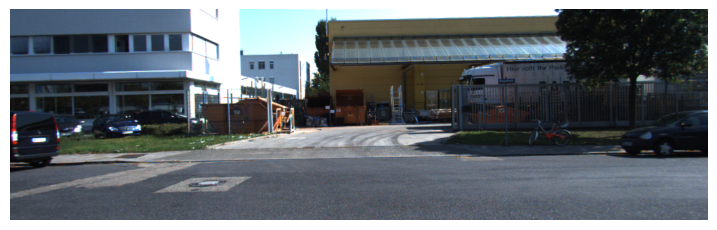

이미지 idx=120: 탐지 0개 -> []


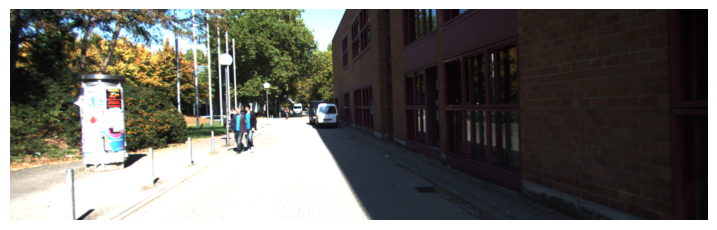

이미지 idx=300: 탐지 0개 -> []


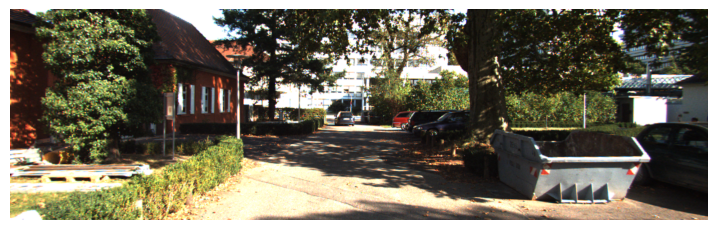

In [23]:
def predict_with_custom_model(pil_image, confidence_threshold=0.3):
    """직접 학습시킨 model(커스텀 RetinaNet)로 추론 -> 원본 이미지 좌표계 bbox 반환."""
    image_tensor = TF.to_tensor(pil_image)
    resized, _, ratio = resize_and_pad_image(image_tensor, training=False)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    normalized = (resized - mean) / std
    input_batch = normalized.unsqueeze(0).to(device)

    # Pass the device to the DecodePredictions constructor
    decoder = DecodePredictions(num_classes=num_classes, confidence_threshold=confidence_threshold, device=device)
    model.eval()
    with torch.no_grad():
        raw = model(input_batch)
        boxes, scores, classes = decoder(input_batch, raw)

    boxes = boxes.cpu() / ratio
    class_names = [KITTI_CLASSES[int(c)] for c in classes]
    return boxes, class_names, scores.cpu()


# 학습에 쓰지 않은 KITTI 이미지 몇 장으로 확인
for idx in [50, 120, 300]:
    image, _ = kitti_train[idx]
    boxes, class_names, scores = predict_with_custom_model(image)
    print(f"이미지 idx={idx}: 탐지 {len(boxes)}개 -> {class_names}")
    visualize_detections(image, boxes, class_names, scores)

> **박스가 부정확하거나 거의 안 잡히면**: `SUBSET_SIZE`/`EPOCHS`를 늘려서 위 학습 셀을 다시 실행하세요
> (체크포인트를 이어받으므로 처음부터 다시 돌릴 필요 없습니다). confidence_threshold를 0.1~0.2로 낮춰서
> 약하게 잡히는 박스까지 보는 것도 진단에 도움이 됩니다.

## 7. 자율주행 보조 시스템 — ADAS 판정 (③)

여기서부터는 실전 정확도(90%+)를 위해 KITTI가 아닌 **torchvision 사전학습 RetinaNet(COCO)**을
인식기로 사용합니다 — 원본 프로젝트 노트북의 설계와 동일합니다 (커스텀 모델은 KITTI 8종 클래스만
학습하고 데이터도 적어, 실전 사람/차량 탐지는 COCO 사전학습 모델이 훨씬 안정적입니다).

In [24]:
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights

coco_weights = RetinaNet_ResNet50_FPN_Weights.COCO_V1
inference_model = retinanet_resnet50_fpn(weights=coco_weights)
inference_model.eval()
print("사전학습 RetinaNet(COCO) 준비 완료")


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:01<00:00, 94.2MB/s]


사전학습 RetinaNet(COCO) 준비 완료


In [30]:
def self_drive_assist(img_path, vehicle_size_limit=280, person_height_limit=110, verbose=False):
    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image).unsqueeze(0)

    with torch.no_grad():
        detections = inference_model(input_tensor)[0]

    PERSON = {1}
    VEHICLES = {2, 3, 4, 6, 8}
    score_threshold = 0.5

    decision = "Go"
    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold:
            continue
        label = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        if verbose:
            print(f"  label={label} score={score:.2f} w={w:.0f} h={h:.0f}")
        if label in PERSON and h >= person_height_limit:
            decision = "Stop"
        if label in VEHICLES and max(w, h) >= vehicle_size_limit:
            decision = "Stop"
    return decision

### 평가 이미지 업로드
stop_1~5.png, go_1~5.png 10장을 선택해서 올려주세요.

In [26]:
ADAS_DATA_DIR = "/content/aiffel/object_detection/data"
os.makedirs(ADAS_DATA_DIR, exist_ok=True)

from google.colab import files
uploaded = files.upload()

import shutil
for fname in uploaded.keys():
    shutil.move(fname, os.path.join(ADAS_DATA_DIR, fname))

print("업로드된 파일:", sorted(os.listdir(ADAS_DATA_DIR)))


Saving go_1.png to go_1.png
Saving go_2.png to go_2.png
Saving go_3.png to go_3.png
Saving go_4.png to go_4.png
Saving go_5.png to go_5.png
Saving person.jpg to person.jpg
Saving stop_1.png to stop_1.png
Saving stop_2.png to stop_2.png
Saving stop_3.png to stop_3.png
Saving stop_4.png to stop_4.png
Saving stop_5.png to stop_5.png
업로드된 파일: ['go_1.png', 'go_2.png', 'go_3.png', 'go_4.png', 'go_5.png', 'person.jpg', 'stop_1.png', 'stop_2.png', 'stop_3.png', 'stop_4.png', 'stop_5.png']


In [32]:
def test_system(func):
    score = 0
    test_set = [
        ("stop_1.png", "Stop"), ("stop_2.png", "Stop"), ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"), ("stop_5.png", "Stop"),
        ("go_1.png", "Go"), ("go_2.png", "Go"), ("go_3.png", "Go"),
        ("go_4.png", "Go"), ("go_5.png", "Go"),
    ]
    for image_file, answer in test_set:
        image_path = os.path.join(ADAS_DATA_DIR, image_file)
        pred = func(image_path)
        mark = "O" if pred == answer else "X"
        print(f"  [{mark}] {image_file}: 정답={answer}, 예측={pred}")
        if pred == answer:
            score += 10
    print(f"\n{score}점입니다. (기준: 90점 이상)")
    return score

test_system(self_drive_assist)


  [O] stop_1.png: 정답=Stop, 예측=Stop
  [O] stop_2.png: 정답=Stop, 예측=Stop
  [O] stop_3.png: 정답=Stop, 예측=Stop
  [O] stop_4.png: 정답=Stop, 예측=Stop
  [O] stop_5.png: 정답=Stop, 예측=Stop
  [O] go_1.png: 정답=Go, 예측=Go
  [O] go_2.png: 정답=Go, 예측=Go
  [O] go_3.png: 정답=Go, 예측=Go
  [O] go_4.png: 정답=Go, 예측=Go
  [O] go_5.png: 정답=Go, 예측=Go

100점입니다. (기준: 90점 이상)


100

### 틀린 이미지 디버깅
점수가 90점 미만이면, 틀린 이미지를 `verbose=True`로 다시 돌려서 실제 탐지된 bbox 크기를 보고
`person_height_limit` / `vehicle_size_limit`을 조정하세요.

In [33]:
# 예시
self_drive_assist(os.path.join(ADAS_DATA_DIR, "go_3.png"), verbose=True)


  label=3 score=0.74 w=27 h=21
  label=3 score=0.65 w=50 h=27
  label=85 score=0.64 w=39 h=36
  label=1 score=0.59 w=17 h=29


'Go'

In [34]:
self_drive_assist(os.path.join(ADAS_DATA_DIR, "stop_3.png"), verbose=True)

  label=3 score=0.93 w=282 h=138
  label=10 score=0.84 w=27 h=64
  label=10 score=0.83 w=29 h=70
  label=3 score=0.77 w=118 h=42


'Stop'

## 요약

- ① KITTI 분석: 1~2절에서 다운로드, 클래스 분포, bbox 시각화까지 실제로 실행됨
- ② RetinaNet 학습+시각화: 5절에서 실제 학습이 진행되고, 6절에서 학습된 모델 자신의 예측 bbox를 시각화함
- ③ ADAS 90%+: 7절 `test_system()` 결과 점수 확인

점수가 부족한 항목이 있으면 위 각 절의 안내(서브셋/epoch 조정, 임계값 조정)를 참고해서 다시 실행하세요.